In [4]:
from pathlib import Path
import sys
import time
import json
import joblib

PROJECT_ROOT = Path.cwd().parent

if str(PROJECT_ROOT) not in sys.path:
    sys.path.append(str(PROJECT_ROOT))

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt

from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix,
)

In [6]:
DATA = PROJECT_ROOT / "data" / "processed"

X_train = pd.read_csv(DATA / "X_train_scaled.csv")

X_test = pd.read_csv(DATA / "X_test_scaled.csv")

y_train = pd.read_csv(DATA / "y_train.csv")["Label"]

y_test = pd.read_csv(DATA / "y_test.csv")["Label"]

label_encoder = joblib.load(DATA / "label_encoder.pkl")

print(X_train.shape)

print(X_test.shape)

(72000, 20)
(18000, 20)


In [7]:
rf = RandomForestClassifier(

    n_estimators=300,

    random_state=42,

    n_jobs=-1
)

start = time.time()

rf.fit(
    X_train,
    y_train
)

training_time = time.time() - start

print()

print("Training Time :", training_time)


Training Time : 78.15048718452454


In [8]:
start = time.time()

y_pred = rf.predict(X_test)

prediction_time = time.time() - start

print()

print("Prediction Time :", prediction_time)


Prediction Time : 0.7626430988311768


In [9]:
accuracy = accuracy_score(
    y_test,
    y_pred
)

precision = precision_score(
    y_test,
    y_pred,
    average="weighted"
)

recall = recall_score(
    y_test,
    y_pred,
    average="weighted"
)

f1 = f1_score(
    y_test,
    y_pred,
    average="weighted"
)

print("="*60)

print("Accuracy :", accuracy)

print("Precision :", precision)

print("Recall :", recall)

print("F1 :", f1)

print("="*60)

Accuracy : 0.9601666666666666
Precision : 0.9602540517817445
Recall : 0.9601666666666666
F1 : 0.9601381058220961


In [10]:
report = classification_report(
    y_test,
    y_pred,
    target_names=label_encoder.classes_
)

print(report)

              precision    recall  f1-score   support

        8PSK       0.88      0.88      0.88      2000
      AM-DSB       1.00      1.00      1.00      2000
      AM-SSB       0.96      1.00      0.98      2000
        BPSK       0.98      0.98      0.98      2000
       CPFSK       0.96      0.95      0.96      2000
        GFSK       0.98      0.98      0.98      2000
        PAM4       0.99      0.98      0.98      2000
       QAM64       0.98      0.96      0.97      2000
        QPSK       0.91      0.90      0.91      2000

    accuracy                           0.96     18000
   macro avg       0.96      0.96      0.96     18000
weighted avg       0.96      0.96      0.96     18000



In [11]:
cm = confusion_matrix(
    y_test,
    y_pred
)

cm_df = pd.DataFrame(
    cm,
    index=label_encoder.classes_,
    columns=label_encoder.classes_
)

cm_df

,8PSK,AM-DSB,AM-SSB,BPSK,CPFSK,GFSK,PAM4,QAM64,QPSK
8PSK,1765,0,18,1,42,11,1,22,140
AM-DSB,0,1999,0,1,0,0,0,0,0
AM-SSB,0,0,2000,0,0,0,0,0,0
BPSK,0,0,18,1966,0,0,14,1,1
CPFSK,51,0,0,0,1907,17,0,0,25
GFSK,9,1,0,0,21,1965,0,0,4
PAM4,1,0,16,29,0,0,1951,3,0
QAM64,42,0,19,2,0,0,1,1928,8
QPSK,141,0,19,0,10,12,3,13,1802


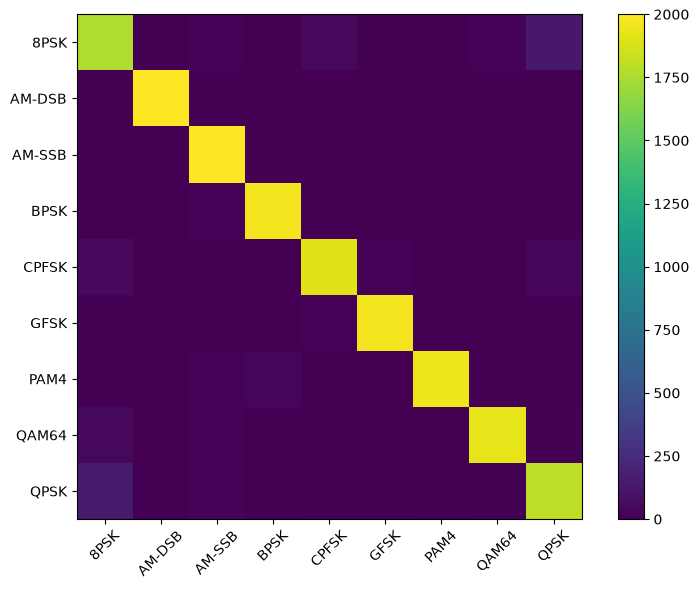

In [12]:
plt.figure(figsize=(8,6))

plt.imshow(cm)

plt.xticks(
    range(len(label_encoder.classes_)),
    label_encoder.classes_,
    rotation=45
)

plt.yticks(
    range(len(label_encoder.classes_)),
    label_encoder.classes_
)

plt.colorbar()

plt.tight_layout()

plt.show()

In [13]:
per_class = cm.diagonal() / cm.sum(axis=1)

per_class_df = pd.DataFrame({

    "Modulation":label_encoder.classes_,

    "Accuracy":per_class

})

per_class_df

,Modulation,Accuracy
0,8PSK,0.8825
1,AM-DSB,0.9995
2,AM-SSB,1.0000
3,BPSK,0.9830
4,CPFSK,0.9535
5,GFSK,0.9825
6,PAM4,0.9755
7,QAM64,0.9640
8,QPSK,0.9010


In [14]:
importance = pd.DataFrame({

    "Feature":X_train.columns,

    "Importance":rf.feature_importances_

})

importance = importance.sort_values(

    by="Importance",

    ascending=False

)

importance

,Feature,Importance
13,M20,0.106188
1,AmplitudeStd,0.088279
4,FrequencyStd,0.084285
7,SigmaZ2,0.080459
3,PhaseStd,0.068639
15,R1,0.062281
6,SigmaDP,0.060756
8,BlindSNR,0.050119
18,R4,0.047946
10,SpectralEntropy,0.045435


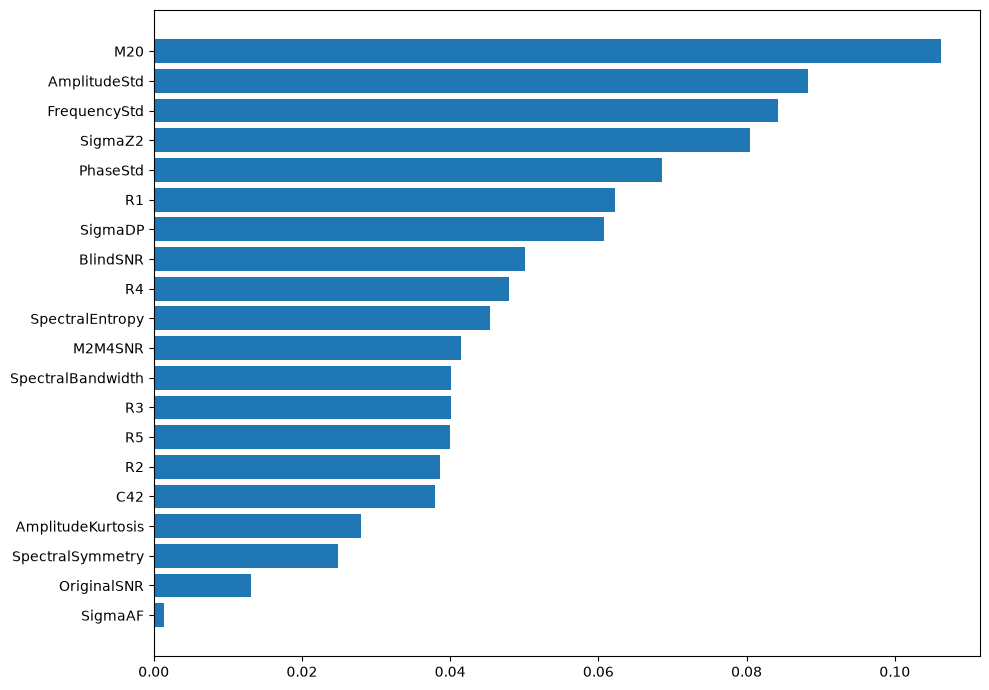

In [15]:
plt.figure(figsize=(10,7))

plt.barh(

    importance["Feature"],

    importance["Importance"]

)

plt.gca().invert_yaxis()

plt.tight_layout()

plt.show()

In [70]:
original = pd.read_csv(DATA / "feature_dataset_clean.csv")

test_index = y_test.index

snr = original.loc[test_index, "OriginalSNR"]

results = pd.DataFrame({

    "Actual":y_test,

    "Predicted":y_pred,

    "SNR":snr

})

snr_accuracy = results.groupby("SNR").apply(

    lambda x:(x.Actual==x.Predicted).mean()

)

snr_accuracy

SNR
0     0.966000
2     0.959000
4     0.961000
6     0.958667
8     0.960000
10    0.966000
12    0.957667
14    0.961000
16    0.962000
dtype: float64

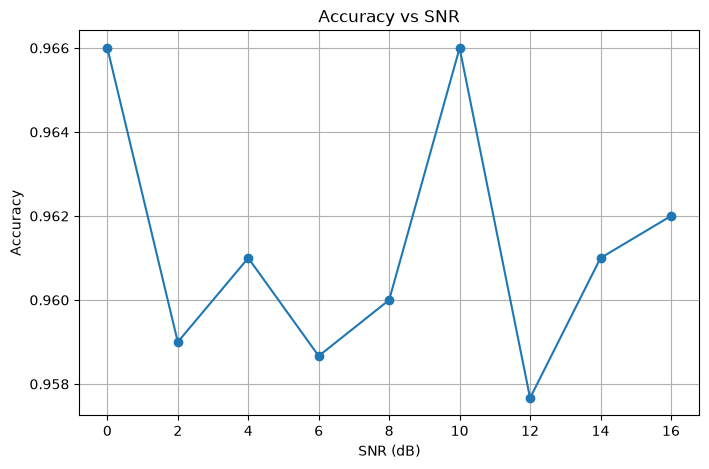

In [71]:
plt.figure(figsize=(8,5))

plt.plot(

    snr_accuracy.index,

    snr_accuracy.values,

    marker="o"

)

plt.grid(True)

plt.xlabel("SNR (dB)")

plt.ylabel("Accuracy")

plt.title("Accuracy vs SNR")

plt.show()

In [72]:
UNKNOWN_THRESHOLD = 0.75

def predict_signal(sample):

    prob = rf.predict_proba(sample)

    confidence = np.max(prob)

    prediction = np.argmax(prob)

    if confidence < UNKNOWN_THRESHOLD:

        return "Unknown", confidence

    return label_encoder.inverse_transform([prediction])[0], confidence

In [73]:
prediction, confidence = predict_signal(

    X_test.iloc[[0]]

)

print(prediction)

print(confidence)

PAM4
1.0


In [ ]:
MODEL = PROJECT_ROOT / "models"

MODEL.mkdir(

    parents=True,

    exist_ok=True

)

joblib.dump(

    rf,

    MODEL / "random_forest.pkl"

)

UNKNOWN_THRESHOLD = 0.75

metadata = {

    "accuracy":float(accuracy),

    "precision":float(precision),

    "recall":float(recall),

    "f1":float(f1),

    "training_time":training_time,

    "prediction_time":prediction_time,

    "threshold":UNKNOWN_THRESHOLD

}

with open(

    MODEL / "random_forest_metadata.json",

    "w"

) as f:

    json.dump(

        metadata,

        f,

        indent=4

    )

print("Model Saved Successfully")

Model Saved Successfully


In [75]:
REPORT = PROJECT_ROOT / "results" / "reports"

REPORT.mkdir(

    parents=True,

    exist_ok=True

)

importance.to_csv(

    REPORT / "feature_importance.csv",

    index=False

)

per_class_df.to_csv(

    REPORT / "per_class_accuracy.csv",

    index=False

)

cm_df.to_csv(

    REPORT / "confusion_matrix.csv"

)

print("Reports Saved")

Reports Saved


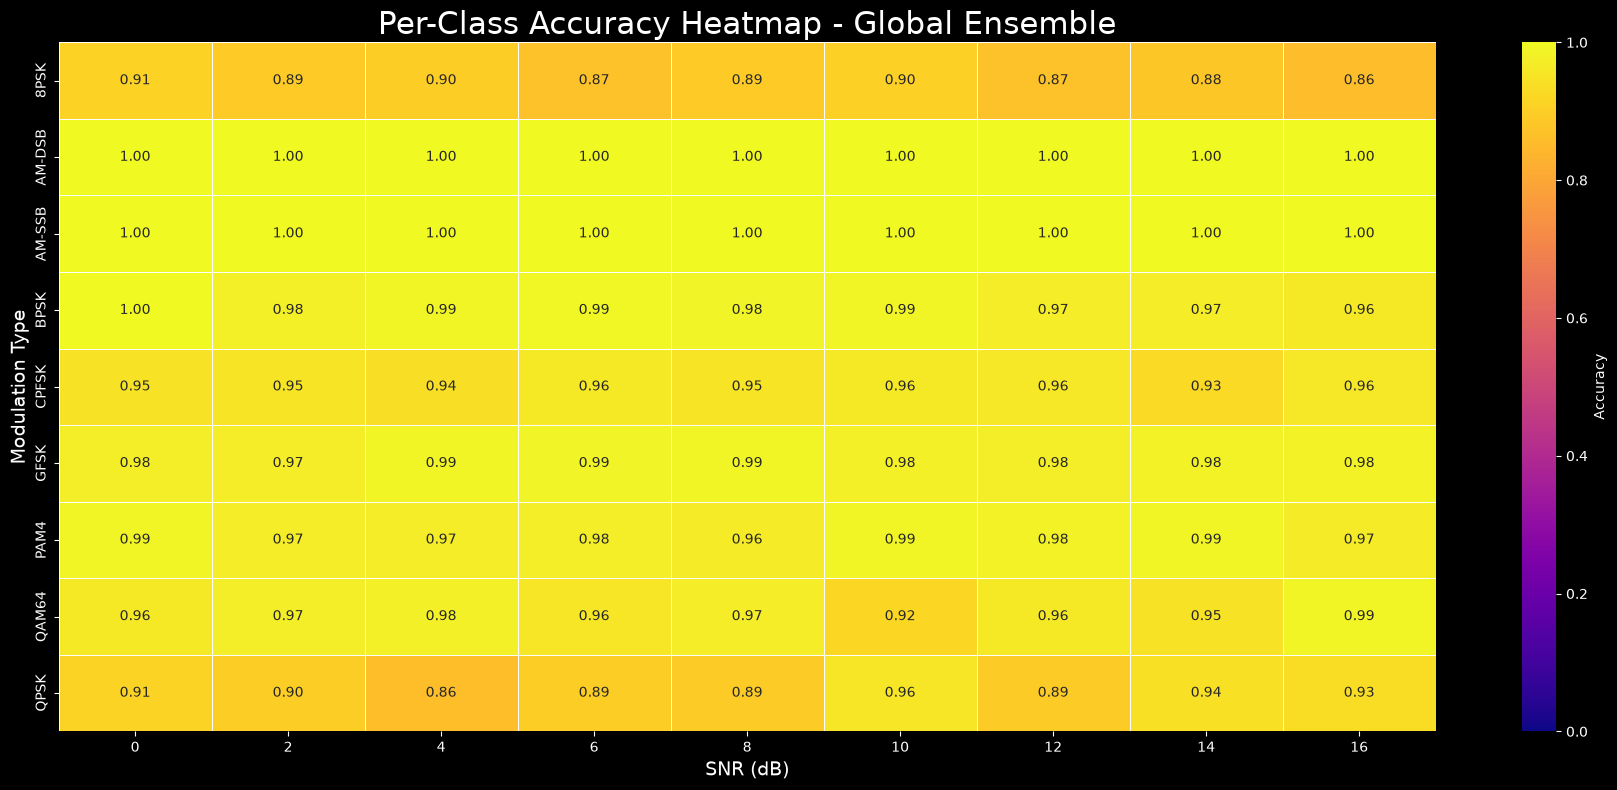

In [16]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Decode labels if necessary
try:
    actual = label_encoder.inverse_transform(np.array(y_test).astype(int))
    predicted = label_encoder.inverse_transform(np.array(y_pred).astype(int))
except:
    actual = np.array(y_test)
    predicted = np.array(y_pred)

# Load original dataset
original = pd.read_csv(DATA / "feature_dataset_clean.csv")

# Get SNR corresponding to test samples
snr = original.loc[y_test.index, "OriginalSNR"].reset_index(drop=True)

# Create results dataframe
results = pd.DataFrame({
    "Actual": actual,
    "Predicted": predicted,
    "SNR": snr
})

# Classes and SNR values
classes = sorted(results["Actual"].unique())
snr_values = sorted(results["SNR"].unique())

# Compute heatmap
heatmap = np.full((len(classes), len(snr_values)), np.nan)

for i, cls in enumerate(classes):
    for j, snr in enumerate(snr_values):

        subset = results[
            (results["Actual"] == cls) &
            (results["SNR"] == snr)
        ]

        if len(subset) > 0:
            heatmap[i, j] = (
                subset["Actual"] == subset["Predicted"]
            ).mean()

# Plot
plt.style.use("dark_background")

plt.figure(figsize=(18,8))

sns.heatmap(
    heatmap,
    annot=True,
    fmt=".2f",
    cmap="plasma",
    xticklabels=snr_values,
    yticklabels=classes,
    linewidths=0.5,
    vmin=0,
    vmax=1,
    cbar_kws={"label": "Accuracy"}
)

plt.title("Per-Class Accuracy Heatmap - Global Ensemble", fontsize=22)

plt.xlabel("SNR (dB)", fontsize=14)
plt.ylabel("Modulation Type", fontsize=14)

plt.tight_layout()
plt.show()

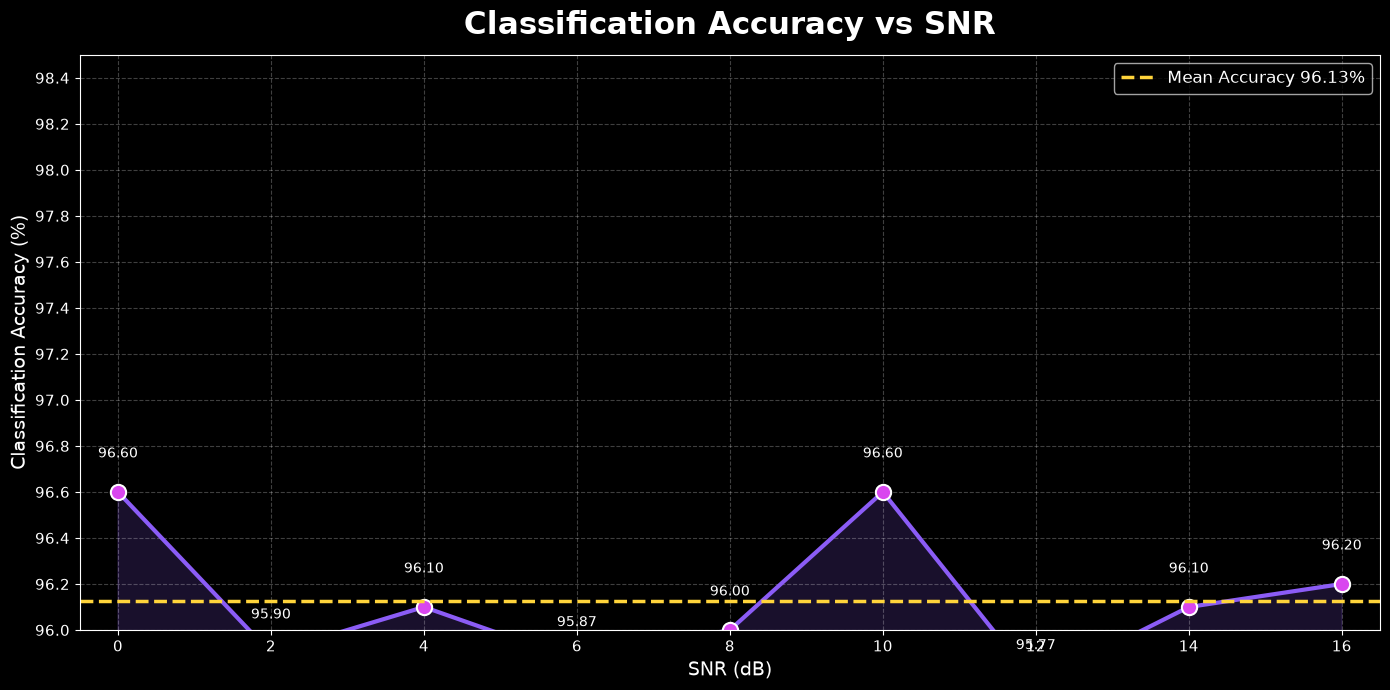

In [18]:
import matplotlib.pyplot as plt
import numpy as np

plt.style.use("dark_background")

snr_accuracy = results.groupby("SNR").apply(
    lambda frame: (frame["Actual"] == frame["Predicted"]).mean()
).sort_index()

snr = snr_accuracy.index.astype(int)
accuracy = snr_accuracy.values * 100

overall = accuracy.mean()

plt.figure(figsize=(14,7))

plt.plot(
    snr,
    accuracy,
    color="#8B5CF6",
    linewidth=3,
    marker="o",
    markersize=11,
    markerfacecolor="#d946ef",
    markeredgecolor="white",
    markeredgewidth=1.5
)

plt.fill_between(
    snr,
    accuracy,
    color="#8B5CF6",
    alpha=0.18
)

plt.axhline(
    overall,
    color="#FFD43B",
    linestyle="--",
    linewidth=2.5,
    label=f"Mean Accuracy {overall:.2f}%"
)

# Annotate every point
for x, y in zip(snr, accuracy):
    plt.text(
        x,
        y + 0.15,
        f"{y:.2f}",
        ha="center",
        fontsize=10,
        color="white"
    )

plt.xticks(snr, fontsize=11)
plt.yticks(np.arange(96, 98.6, 0.2), fontsize=11)

plt.xlim(snr.min()-0.5, snr.max()+0.5)
plt.ylim(96, 98.5)

plt.grid(True, linestyle="--", alpha=0.25)

plt.xlabel("SNR (dB)", fontsize=14)
plt.ylabel("Classification Accuracy (%)", fontsize=14)

plt.title(
    "Classification Accuracy vs SNR",
    fontsize=22,
    weight="bold",
    pad=15
)

plt.legend(fontsize=12)

plt.tight_layout()
plt.show()

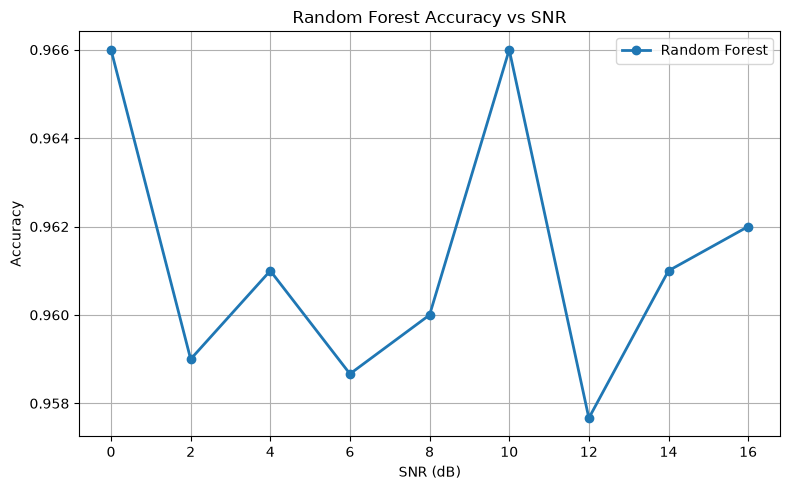

Saved : rf_accuracy_vs_snr.csv


,OriginalSNR,Accuracy
0,0,0.966000
1,2,0.959000
2,4,0.961000
3,6,0.958667
4,8,0.960000
5,10,0.966000
6,12,0.957667
7,14,0.961000
8,16,0.962000


In [7]:
from pathlib import Path
import pandas as pd
import joblib
from sklearn.metrics import accuracy_score

# ---------------------------------------------------------
# Ensure model is available even if earlier training cells were not run
# ---------------------------------------------------------

try:
    rf
except NameError:
    rf = joblib.load(PROJECT_ROOT / "models" / "random_forest.pkl")

# ---------------------------------------------------------
# Predictions
# ---------------------------------------------------------

rf_predictions = rf.predict(X_test)

# ---------------------------------------------------------
# Create Results DataFrame
# ---------------------------------------------------------

original = pd.read_csv(DATA / "feature_dataset_clean.csv")
snr = original.loc[y_test.index, "OriginalSNR"].reset_index(drop=True)

snr_results = pd.DataFrame({

    "OriginalSNR": snr,

    "Actual": y_test.values,

    "Prediction": rf_predictions

})

# ---------------------------------------------------------
# Accuracy vs SNR
# ---------------------------------------------------------

accuracy_vs_snr = (

    snr_results

    .groupby("OriginalSNR")

    .apply(lambda x: accuracy_score(x["Actual"], x["Prediction"]))

    .reset_index(name="Accuracy")

    .sort_values("OriginalSNR")

)

# ---------------------------------------------------------
# Save
# ---------------------------------------------------------

REPORT_DIR = PROJECT_ROOT / "results" / "reports"

REPORT_DIR.mkdir(
    parents=True,
    exist_ok=True
)

accuracy_vs_snr.to_csv(

    REPORT_DIR / "rf_accuracy_vs_snr.csv",

    index=False

)

# ---------------------------------------------------------
# Plot
# ---------------------------------------------------------

import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))

plt.plot(

    accuracy_vs_snr["OriginalSNR"],

    accuracy_vs_snr["Accuracy"],

    marker="o",

    linewidth=2,

    label="Random Forest"

)

plt.xlabel("SNR (dB)")

plt.ylabel("Accuracy")

plt.title("Random Forest Accuracy vs SNR")

plt.grid(True)

plt.legend()

plt.tight_layout()

plt.show()

print("="*60)
print("Saved : rf_accuracy_vs_snr.csv")
print("="*60)

accuracy_vs_snr